In [2]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
import torch
import numpy as np
import pandas as pd

# Load data
data = fetch_20newsgroups(subset='all', categories=['sci.med', 'sci.space'], remove=('headers', 'footers', 'quotes'))
df = pd.DataFrame({'text': data.data, 'label': data.target})

# Split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)

# Embed
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model_bert = AutoModel.from_pretrained("distilbert-base-uncased")
model_bert.eval()

def get_embeddings(texts, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size].tolist()
        encoded = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors='pt')
        with torch.no_grad():
            output = model_bert(**encoded)
        embeddings = output.last_hidden_state[:, 0, :].numpy()
        all_embeddings.append(embeddings)
    return np.vstack(all_embeddings)

X_train_bert = get_embeddings(X_train.reset_index(drop=True))
X_test_bert = get_embeddings(X_test.reset_index(drop=True))

# Train
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_bert, y_train)
y_pred_bert = model_lr.predict(X_test_bert)
print("Ready.")

Ready.


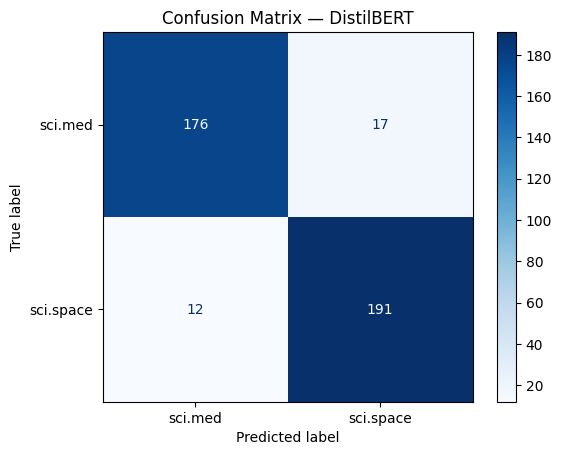

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_bert)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['sci.med', 'sci.space'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — DistilBERT')
plt.show()

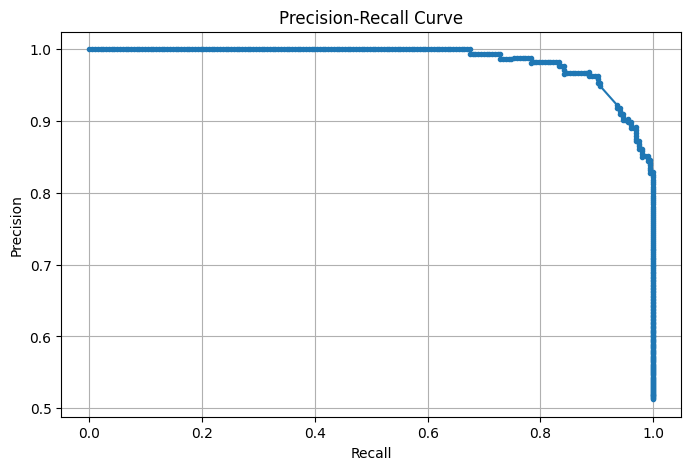

In [4]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_scores = model_lr.predict_proba(X_test_bert)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

Confusion matrix — what each cell means in class-specific terms
Precision-recall tradeoff — lowering threshold increases recall, decreases precision
The curve represents every possible threshold, not just 0.5

ROC-AUC Score: 0.9849


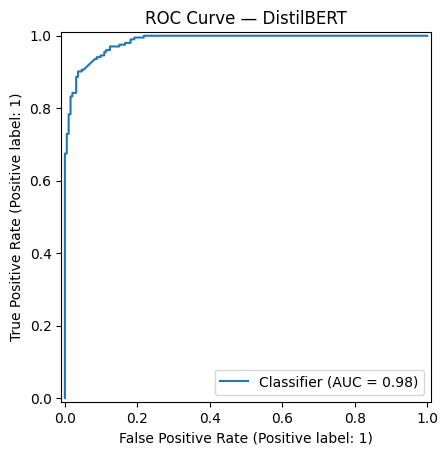

In [5]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

roc_score = roc_auc_score(y_test, y_scores)
print(f"ROC-AUC Score: {roc_score:.4f}")

RocCurveDisplay.from_predictions(y_test, y_scores)
plt.title('ROC Curve — DistilBERT')
plt.show()

ROC-AUC vs PR-AUC
Use ROC-AUC when classes are balanced — it measures overall separability across all thresholds. Use PR-AUC when classes are imbalanced — it focuses specifically on minority class performance, making it more informative when the rare class is what matters.
ROC-AUC 0.5 = random, 1.0 = perfect
A diagonal line on the ROC curve means the model is guessing — true positive rate equals false positive rate at every threshold. A score of 1.0 means perfect separation with the curve hugging the top-left corner. Anything below 0.7 in practice is considered weak.
ROC-AUC higher than F1
F1 is calculated at a single threshold (default 0.5). ROC-AUC evaluates the model across every possible threshold, rewarding good probability separation even when the default threshold isn't optimal. This is why ROC-AUC is almost always higher than F1.


What class weights do mechanically
Class weights tell the loss function to penalize mistakes on the minority class more heavily. During training, a wrong prediction on the minority class causes a larger weight update than a wrong prediction on the majority class. The decision boundary shifts toward catching more minority cases — not because the model got smarter, but because the cost of missing them increased.
Precision/recall tradeoff in imbalanced datasets
Pushing recall higher on the minority class forces the model to flag more borderline cases, increasing false positives and dropping precision. You can't maximize both simultaneously — every threshold choice is a tradeoff between how many real cases you catch vs how many false alarms you generate.
Why accuracy is misleading on imbalanced data
A model that predicts the majority class every time achieves 95% accuracy on a 95/5 dataset while being completely useless. Accuracy rewards the model for exploiting the distribution, not for learning signal. Always check per-class F1 and recall before trusting an accuracy number.
Weighted vs vanilla — business decision
If false negatives are catastrophic (fraud, cancer, security threats) use class weights to maximize recall and accept more false alarms. If false positives are costly (spam filters, content moderation at scale) use the vanilla model and protect precision. The threshold and weights are not tuning decisions — they are business decisions about which mistakes you can afford.Sonnet 4.6